# CS0073 Statistical Analysis and Modeling: Technical Assessment, Module 2
## Diagnostic Analytics and Statistical Inference

| | |
|---|---|
| **Name** | Dawn Andrei Pamesa |
| **Section** | TS31 |
| **Professor** | Jeneffer Sabonsolin |
| **Date Performed** | September 28, 2026 |
| **Date Submitted** | ______________________ |
| **Dataset** | `Customer_Satisfaction.xlsx`, a restaurant customer survey (405 respondents, 13 items on a 1 to 7 scale) |

**How This Notebook Is Organized**

- **Part A, Correlation Analysis** answers the task written in the dataset itself: correlate the ten
  perception indicators with each other and with satisfaction, likelihood to return, and likelihood to recommend.
- **Part B, Hypothesis Test** follows the five tasks in the Module 2 guideline: research question and
  hypotheses, choice of test, assumption checks, the analysis at alpha = 0.05, and a diagnostic report.
- Each result is followed by a **How to Defend This** note in plain language.
- The **Question and Answer** section and the **Appendix: AI Tools and Prompts** close the notebook.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

pd.set_option("display.precision", 4)
ALPHA = 0.05  # significance level used for every test in this notebook

# Chart style: one quiet look for every figure
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": False,
    "font.size": 10,
})
FIG_DIR = "PAMESA - M2-Technical - Figures"
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load and Clean the Data

In [2]:
DATA_FILE = "Customer_Satisfaction.xlsx"

# The "Questions" sheet is the codebook: item code and wording
questions = pd.read_excel(DATA_FILE, sheet_name="Questions", header=None,
                          usecols="A:B", skiprows=1, names=["code", "question"])
questions["question"] = questions["question"].str.strip()

raw = pd.read_excel(DATA_FILE, sheet_name="Survey Responses")
raw_shape = raw.shape
print("Raw sheet shape (rows, columns):", raw_shape)
print("Columns:", list(raw.columns))
questions

Raw sheet shape (rows, columns): (405, 17)
Columns: ['id', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']


,code,question
0,x12,has friendly employees
1,x13,is a fun place to eat
2,x14,has large size portions
3,x15,has fresh food
4,x16,has reasonable prices
5,x17,has an attractive interior
6,x18,has excellent food taste
7,x19,has knowledgeable employees
8,x20,serves food at the proper temperature
9,x21,has quick service


In [3]:
VARS =[f"x{i}" for i in range(12, 25)]      # the 13 survey items
PERCEPTION = VARS[:10]                        # x12 to x21: how the customer sees the restaurant
OUTCOMES = ["x22", "x23", "x24"]              # satisfaction, return, recommend
SHORT = {
    "x12": "Friendly employees", "x13": "Fun place to eat", "x14": "Large portions",
    "x15": "Fresh food", "x16": "Reasonable prices", "x17": "Attractive interior",
    "x18": "Excellent food taste", "x19": "Knowledgeable employees",
    "x20": "Proper food temperature", "x21": "Quick service",
    "x22": "Satisfaction", "x23": "Likely to return", "x24": "Likely to recommend",
}

# Cleaning: keep the id and the 13 items. The other columns are empty except for the
# instructor's task note typed beside the data, which is text, not responses.
dropped_cols = [c for c in raw.columns if c not in ["id"] + VARS]
print("Non-empty cells in the dropped columns:", raw[dropped_cols].notna().sum().to_dict())
df = raw[["id"] + VARS].copy()

n_rows = len(df)
n_missing = int(df.isna().sum().sum())
n_duplicate_ids = int(df["id"].duplicated().sum())
n_out_of_range = int(((df[VARS] < 1) | (df[VARS] > 7)).sum().sum())
n_non_integer = int((df[VARS] % 1 != 0).sum().sum())

pd.Series({"rows (respondents)": n_rows, "missing values": n_missing,
           "duplicate ids": n_duplicate_ids, "answers outside 1 to 7": n_out_of_range,
           "non-whole-number answers": n_non_integer}, name="data quality check")

Non-empty cells in the dropped columns: {'Unnamed: 14': 0, 'Unnamed: 15': 0, 'Unnamed: 16': 2}


rows (respondents)          405
missing values                0
duplicate ids                 0
answers outside 1 to 7        0
non-whole-number answers      0
Name: data quality check, dtype: int64

> **How to Defend This.** The sheet has 405 respondents and no missing values, no duplicate ids,
> and no answers outside the 1 to 7 scale, so nothing had to be removed or filled in. The only cleaning
> needed was dropping 3 non-data columns: they are empty except for the instructor's
> task note typed next to the table. If asked "did you clean the data?", the answer is: yes, I checked
> it for missing values, duplicates and impossible values, found none, and removed the columns that
> were not survey responses.

## 2. Descriptive Context

In [4]:
desc = df[VARS].agg(["count", "mean", "std", "median", "min", "max"]).T
desc.insert(0, "question", [SHORT[v] for v in VARS])
desc_means = desc["mean"]
desc.round(2)

,question,count,mean,std,median,min,max
x12,Friendly employees,405.0,3.64,1.21,4.0,1.0,5.0
x13,Fun place to eat,405.0,4.64,0.91,5.0,2.0,7.0
x14,Large portions,405.0,4.51,1.32,5.0,2.0,6.0
x15,Fresh food,405.0,5.76,1.20,6.0,4.0,7.0
x16,Reasonable prices,405.0,4.34,1.24,4.0,2.0,6.0
x17,Attractive interior,405.0,4.70,1.02,5.0,2.0,7.0
x18,Excellent food taste,405.0,5.31,1.08,5.0,3.0,7.0
x19,Knowledgeable employees,405.0,3.55,1.52,4.0,1.0,7.0
x20,Proper food temperature,405.0,4.52,1.17,5.0,2.0,7.0
x21,Quick service,405.0,5.21,2.04,7.0,1.0,7.0


> **How to Defend This.** Every item is on a 1 to 7 scale, so a mean above 4 leans toward agreement.
> Customers rate **fresh food** highest (mean 5.76) and **knowledgeable
> employees** lowest (mean 3.55). **Quick service** has by far the largest spread
> (SD 2.04) because customers are split: 218 of
> 405 gave it a 7 while 110 gave 3 or lower. Two ranges are restricted:
> nobody rated fresh food below 4, and nobody rated friendly employees above
> 5. Treating 1 to 7 answers as numbers (taking means) assumes the steps
> are roughly equal; that is common practice for 7-point scales, and I note it as a limitation.

# Part A. Correlation Analysis

**Task written in the dataset:** get the correlation of the perception indicators with each other, as
well as with customer satisfaction, likelihood to return, and likelihood to recommend.

**Association versus correlation.** *Association* is the general idea that two variables are related
in any way (including categorical variables and curved patterns). A *correlation coefficient* is a
specific number for the strength and direction of a **linear** relationship between two numeric
variables. Pearson's r runs from -1 (perfect negative line) through 0 (no linear relationship) to +1
(perfect positive line). Correlation says two things move together; it does not say either one causes
the other.

In [5]:
corr = df[VARS].corr(method="pearson")
corr.round(2)

,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24
x12,1.00,-0.15,-0.04,0.36,-0.05,-0.11,0.36,0.60,0.02,0.81,0.42,0.36,0.19
x13,-0.15,1.00,0.39,-0.01,0.38,0.67,0.03,0.12,0.09,-0.05,0.22,0.23,0.27
x14,-0.04,0.39,1.00,0.14,0.96,0.29,0.04,0.09,0.08,0.02,0.31,0.27,0.31
x15,0.36,-0.01,0.14,1.00,0.16,-0.00,0.79,0.39,0.50,0.11,0.56,0.50,0.47
x16,-0.05,0.38,0.96,0.16,1.00,0.27,0.11,0.12,0.11,-0.01,0.30,0.28,0.30
x17,-0.11,0.67,0.29,-0.00,0.27,1.00,-0.08,0.08,0.19,-0.06,0.20,0.27,0.25
x18,0.36,0.03,0.04,0.79,0.11,-0.08,1.00,0.38,0.59,0.16,0.44,0.45,0.37
x19,0.60,0.12,0.09,0.39,0.12,0.08,0.38,1.00,0.19,0.50,0.40,0.45,0.34
x20,0.02,0.09,0.08,0.50,0.11,0.19,0.59,0.19,1.00,0.04,0.50,0.52,0.50
x21,0.81,-0.05,0.02,0.11,-0.01,-0.06,0.16,0.50,0.04,1.00,0.38,0.32,0.16


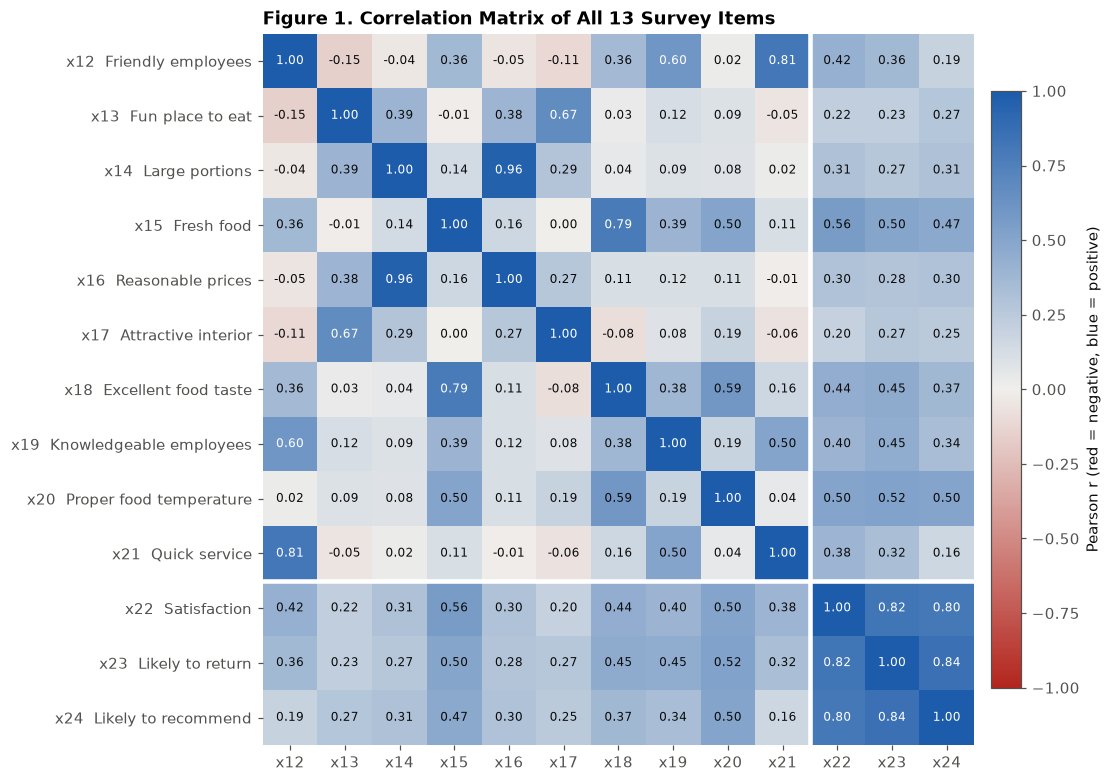

In [6]:
labels = [f"{v}  {SHORT[v]}" for v in VARS]
cmap = LinearSegmentedColormap.from_list("div", ["#b3261e", "#f0efec", "#1c5cab"])
fig, ax = plt.subplots(figsize=(10, 8.4))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(VARS)), VARS)
ax.set_yticks(range(len(VARS)), labels)
for i in range(len(VARS)):
    for j in range(len(VARS)):
        r = corr.values[i, j]
        ax.text(j, i, f"{r:.2f}".replace("-0.00", "0.00"), ha="center", va="center", fontsize=8,
                color="white" if abs(r) >= 0.6 else INK)
ax.axhline(9.5, color="white", lw=3); ax.axvline(9.5, color="white", lw=3)  # perception | outcomes
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Pearson r (red = negative, blue = positive)")
ax.set_title("Figure 1. Correlation Matrix of All 13 Survey Items", loc="left")
fig.savefig(os.path.join(FIG_DIR, "Figure 1 - Correlation Matrix.png"))
plt.show()

> **How to Defend This (Figure 1).** Each square is the correlation between the row item and the column
> item; darker blue means a stronger positive relationship, red would mean negative, and the diagonal is
> 1 because every item correlates perfectly with itself. The white lines separate the ten perception items
> from the three outcomes (bottom-right block). The outcomes are very strongly related to each other
> (r = 0.82 to 0.84): satisfied customers also say they
> will return and recommend.

In [7]:
N = len(df)
df_r = N - 2                                   # degrees of freedom for testing r
t_crit = stats.t.ppf(1 - ALPHA / 2, df_r)
r_crit = t_crit / np.sqrt(t_crit**2 + df_r)    # smallest |r| that is significant at ALPHA
print(f"n = {N}, df = {df_r}: any |r| above {r_crit:.3f} is significant at alpha = {ALPHA}")

n = 405, df = 403: any |r| above 0.097 is significant at alpha = 0.05


> **How to Defend This.** With 405 respondents, any correlation bigger than 0.097 in absolute
> value is statistically significant. That is a very low bar, which is why almost every p-value below is
> tiny. So in this analysis the **size** of r matters more than whether it is significant: a correlation
> of 0.15 is "significant" here but still weak.

In [8]:
def strength(r):
    """Rule-of-thumb label for |r| used in this report."""
    a = abs(r)
    if a < 0.10: return "negligible"
    if a < 0.30: return "weak"
    if a < 0.50: return "moderate"
    if a < 0.70: return "strong"
    return "very strong"

rows = []
for x in PERCEPTION:
    for y in OUTCOMES:
        res = stats.pearsonr(df[x], df[y])
        rows.append({"indicator": x, "outcome": y, "r": res.statistic, "p": res.pvalue})
pairs = pd.DataFrame(rows)
r_outcomes = pairs.pivot(index="indicator", columns="outcome", values="r").loc[PERCEPTION, OUTCOMES]
p_outcomes = pairs.pivot(index="indicator", columns="outcome", values="p").loc[PERCEPTION, OUTCOMES]

outcome_table = pd.DataFrame({"question": [SHORT[x] for x in PERCEPTION]}, index=PERCEPTION)
for y in OUTCOMES:
    outcome_table[f"r {y}"] = r_outcomes[y].round(3)
    outcome_table[f"p {y}"] = p_outcomes[y].map(lambda p: f"{p:.2e}")
    outcome_table[f"strength {y}"] = r_outcomes[y].map(strength)
outcome_table.sort_values("r x22", ascending=False)

,question,r x22,p x22,strength x22,r x23,p x23,strength x23,r x24,p x24,strength x24
x15,Fresh food,0.559,1.34e-34,strong,0.496,1.52e-26,moderate,0.471,1.03e-23,moderate
x20,Proper food temperature,0.504,1.61e-27,strong,0.517,4.16e-29,strong,0.505,1.36e-27,strong
x18,Excellent food taste,0.440,1.35e-20,moderate,0.454,5.70e-22,moderate,0.372,1.04e-14,moderate
x12,Friendly employees,0.425,3.66e-19,moderate,0.361,6.74e-14,moderate,0.191,1.14e-04,weak
x19,Knowledgeable employees,0.397,9.64e-17,moderate,0.446,3.34e-21,moderate,0.335,4.45e-12,moderate
x21,Quick service,0.384,1.17e-15,moderate,0.324,2.43e-11,moderate,0.163,9.68e-04,weak
x14,Large portions,0.308,2.40e-10,moderate,0.268,4.17e-08,weak,0.308,2.42e-10,moderate
x16,Reasonable prices,0.298,1.01e-09,weak,0.281,8.22e-09,weak,0.304,3.91e-10,moderate
x13,Fun place to eat,0.219,8.60e-06,weak,0.225,4.80e-06,weak,0.274,2.17e-08,weak
x17,Attractive interior,0.196,7.45e-05,weak,0.273,2.39e-08,weak,0.248,4.13e-07,weak


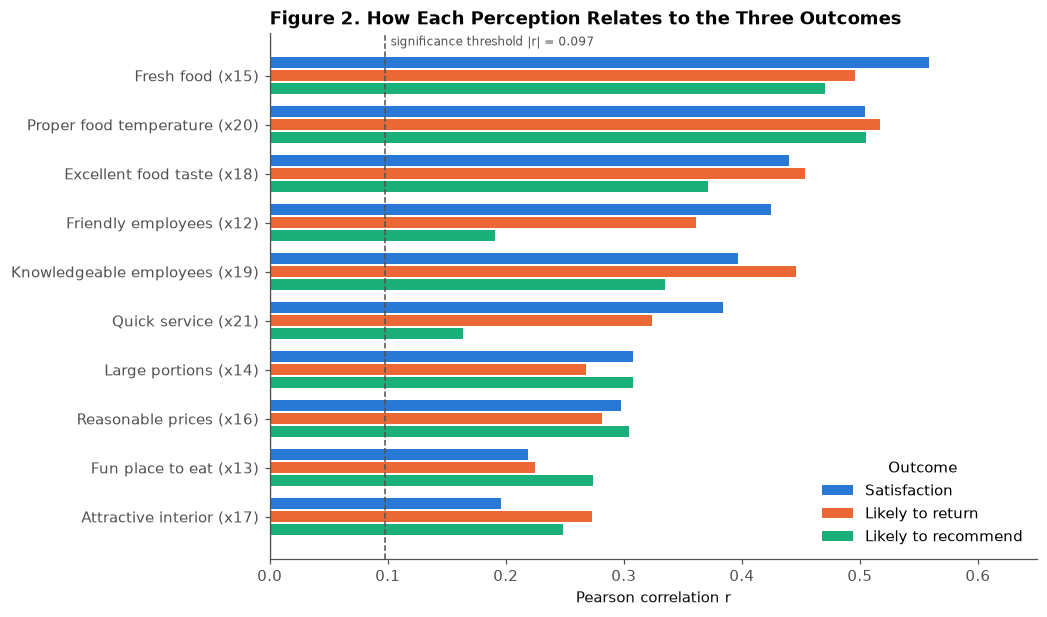

In [9]:
order = r_outcomes["x22"].sort_values().index          # weakest at the bottom of the list
y_pos = np.arange(len(order))
h = 0.26
fig, ax = plt.subplots(figsize=(9, 6.2))
for k, (col, color) in enumerate(zip(OUTCOMES, [BLUE, ORANGE, AQUA])):
    ax.barh(y_pos + (1 - k) * h, r_outcomes.loc[order, col], height=h - 0.04,
            color=color, label=SHORT[col])
ax.axvline(r_crit, color=MUTED, ls="--", lw=1)
ax.text(r_crit + 0.005, len(order) - 0.45, f"significance threshold |r| = {r_crit:.3f}",
        color=MUTED, fontsize=8, va="bottom")
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_yticks(y_pos, [f"{SHORT[v]} ({v})" for v in order])
ax.set_xlabel("Pearson correlation r")
ax.set_xlim(0, 0.65)
ax.legend(title="Outcome", frameon=False, loc="lower right")
ax.set_title("Figure 2. How Each Perception Relates to the Three Outcomes", loc="left")
fig.savefig(os.path.join(FIG_DIR, "Figure 2 - Perception vs Outcomes.png"))
plt.show()

> **How to Defend This (Table and Figure 2).** The perception most strongly related to **satisfaction** is
> **fresh food** (r = 0.559, strong),
> then **proper food temperature** (r = 0.504). The weakest is **attractive
> interior** (r = 0.196, weak). For
> **recommending**, food temperature (r = 0.505) and fresh food
> (r = 0.471) lead, while quick service barely matters
> (r = 0.163). All 30 of the 30
> correlations are significant at alpha = 0.05 and all are positive: every perception moves in the same
> direction as the outcomes. In short, food quality (freshness, temperature, taste) is the clearest link to
> how customers feel; the dining room matters least.

In [10]:
mask = np.triu(np.ones((len(PERCEPTION), len(PERCEPTION)), dtype=bool), k=1)
upper = corr.loc[PERCEPTION, PERCEPTION].where(mask)
strong_pairs = upper.stack().reset_index()
strong_pairs.columns = ["item 1", "item 2", "r"]
strong_pairs = strong_pairs[strong_pairs["r"].abs() >= 0.5].sort_values("r", ascending=False)
strong_pairs["meaning"] = [f"{SHORT[a]} and {SHORT[b]}" for a, b in zip(strong_pairs["item 1"], strong_pairs["item 2"])]
n_strong_pairs = len(strong_pairs)
strong_pairs.round(3)

,item 1,item 2,r,meaning
18,x14,x16,0.959,Large portions and Reasonable prices
8,x12,x21,0.810,Friendly employees and Quick service
26,x15,x18,0.789,Fresh food and Excellent food taste
12,x13,x17,0.672,Fun place to eat and Attractive interior
6,x12,x19,0.601,Friendly employees and Knowledgeable employees
40,x18,x20,0.589,Excellent food taste and Proper food temperature
43,x19,x21,0.504,Knowledgeable employees and Quick service
28,x15,x20,0.502,Fresh food and Proper food temperature


> **How to Defend This.** Some perceptions travel together. **Large portions and reasonable prices** are
> almost the same answer (r = 0.96), which suggests customers judge them together as
> "value for money". **Friendly employees and quick service** (r = 0.81) and
> **fresh food and excellent taste** (r = 0.79) are also very strongly linked. This
> matters for Part B: because freshness and taste move together, any difference we find across freshness
> levels may partly be a taste effect. The few negative correlations are tiny (the lowest is
> r = -0.15).

In [11]:
spearman = df[VARS].corr(method="spearman")
max_diff = float((spearman - corr).abs().max().max())
top_pearson = r_outcomes["x22"].idxmax()
top_spearman = spearman.loc[PERCEPTION, "x22"].idxmax()
print(f"Largest gap between Spearman and Pearson anywhere in the matrix: {max_diff:.3f}")
print(f"Strongest correlate of satisfaction: Pearson -> {top_pearson}, Spearman -> {top_spearman}")

Largest gap between Spearman and Pearson anywhere in the matrix: 0.068
Strongest correlate of satisfaction: Pearson -> x15, Spearman -> x15


> **How to Defend This.** Survey answers on a 1 to 7 scale are ordered categories, so Pearson's r (which
> treats them as numbers) could be questioned. Spearman's correlation uses only the rank order. The two
> never differ by more than 0.068, and both pick fresh food as the strongest
> correlate of satisfaction, so the conclusions do not depend on that choice.

**Part A Summary.** All ten perceptions are positively related to satisfaction, return and recommendation.
Food quality matters most: fresh food (r = 0.56) and proper temperature
(r = 0.50) have the strongest links with satisfaction, while the interior and
the fun atmosphere have the weakest. Because correlation cannot tell us whether satisfaction truly differs
between groups of customers, Part B tests that directly for the strongest correlate, fresh food.

# Part B. Hypothesis Test

## Task 1. Research Question, Hypotheses and Variables

**Research question.** Does customer satisfaction differ across levels of perceived food freshness?

- **Null hypothesis (H0):** mean satisfaction is the same at every freshness rating
  (mu_4 = mu_5 = mu_6 = mu_7).
- **Alternative hypothesis (H1):** at least one freshness level has a different mean satisfaction.

| Variable | Role | Measurement type | How it is used |
|---|---|---|---|
| x15, "has fresh food" | Independent (grouping factor) | Ordinal, 7-point agreement scale | Four groups, one per observed answer (4, 5, 6, 7); nobody answered below 4 |
| x22, "satisfaction rating" | Dependent (outcome) | Ordinal, 7-point scale, treated as approximately interval | Compared across the four groups using the group means |

**Why this pair.** Part A found fresh food to be the strongest correlate of satisfaction. A correlation
only says the two rise together; the diagnostic question is whether customers who rate freshness
higher are actually more satisfied as groups, and by how much.

## Task 2. Choosing the Test

In [12]:
GROUP_LEVELS = [int(g) for g in sorted(df["x15"].unique())]
group_sizes = df["x15"].value_counts().sort_index()
k_groups = len(GROUP_LEVELS)
n_pairwise = k_groups * (k_groups - 1) // 2
familywise_error = 1 - (1 - ALPHA) ** n_pairwise
print("Freshness levels present:", GROUP_LEVELS)
print(f"{n_pairwise} pairwise t-tests would give a {familywise_error:.1%} chance of at least one false positive")
group_sizes.rename("respondents per freshness level")

Freshness levels present: [4, 5, 6, 7]
6 pairwise t-tests would give a 26.5% chance of at least one false positive


x15
4     85
5     93
6     60
7    167
Name: respondents per freshness level, dtype: int64

> **How to Defend This (Justification).** The outcome (satisfaction) is compared across **4
> groups** (freshness ratings 4, 5, 6, 7, with
> 85, 93, 60, 167 respondents), so the right test is a **one-way
> ANOVA**.
> 
> - A **t-test** compares only two groups. Doing all 6 pairs separately would raise the chance of
>   a false "significant" result to about 26% instead of 5%; ANOVA tests all groups at once.
> - A **Chi-square test of independence** is for two categorical variables. It would treat the 1 to 7
>   satisfaction score as unordered categories and throw away the fact that 6 is higher than 5.

## Task 3. Checking the Assumptions

One-way ANOVA assumes (1) **independent observations**, (2) **roughly normal** satisfaction scores within
each group, and (3) **equal variances** across groups.

In [13]:
groups = [df.loc[df["x15"] == g, "x22"] for g in GROUP_LEVELS]
group_stats = df.groupby("x15")["x22"].agg(n="count", mean="mean", sd="std", median="median")
sd_ratio = group_stats["sd"].max() / group_stats["sd"].min()
print(f"Largest SD / smallest SD = {sd_ratio:.2f}  (rule of thumb: above 2 suggests unequal variances)")
group_stats.round(3)

Largest SD / smallest SD = 2.19  (rule of thumb: above 2 suggests unequal variances)


,n,mean,sd,median
x15,,,,
4,85,3.988,0.587,4.0
5,93,4.355,0.775,4.0
6,60,4.850,1.287,5.0
7,167,5.515,0.993,6.0


In [14]:
shapiro = pd.DataFrame(
    [(g, *stats.shapiro(s)) for g, s in zip(GROUP_LEVELS, groups)],
    columns=["freshness", "W", "p"]).set_index("freshness")
shapiro_p = shapiro["p"].values
shapiro["normal at alpha 0.05?"] = np.where(shapiro["p"] < ALPHA, "no (violated)", "yes")
shapiro

,W,p,normal at alpha 0.05?
freshness,,,
4,0.5804,3.2451e-14,no (violated)
5,0.8137,1.7617e-09,no (violated)
6,0.9034,1.7489e-04,no (violated)
7,0.8559,1.5915e-11,no (violated)


In [15]:
levene_F, levene_p = stats.levene(*groups, center="mean")         # classic Levene (same as the Excel file)
bf_F, bf_p = stats.levene(*groups, center="median")               # Brown-Forsythe version, for comparison
print(f"Levene (mean-centered):     F = {levene_F:.3f}, p = {levene_p:.3g}")
print(f"Brown-Forsythe (median):    F = {bf_F:.3f}, p = {bf_p:.3g}")

Levene (mean-centered):     F = 38.597, p = 6.23e-22
Brown-Forsythe (median):    F = 19.141, p = 1.28e-11


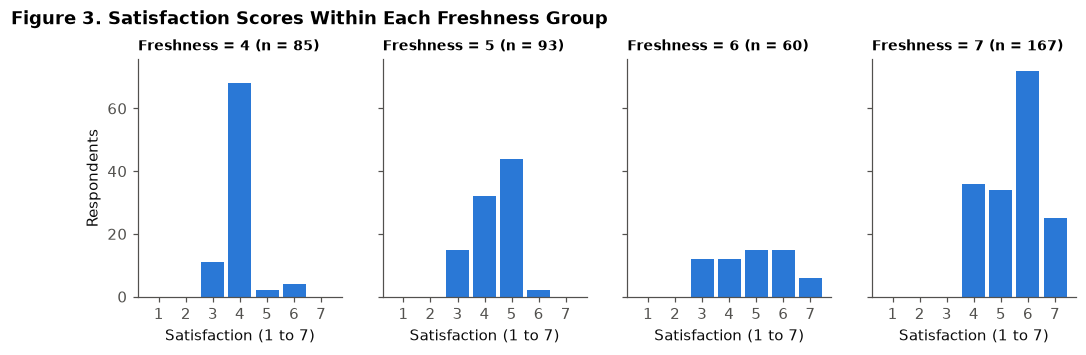

In [16]:
fig, axes = plt.subplots(1, len(GROUP_LEVELS), figsize=(11, 2.8), sharey=True)
bins = np.arange(0.5, 8.5, 1)
for ax, g, s in zip(axes, GROUP_LEVELS, groups):
    ax.hist(s, bins=bins, color=BLUE, rwidth=0.85)
    ax.set_title(f"Freshness = {g} (n = {len(s)})", fontsize=9, loc="left")
    ax.set_xticks(range(1, 8))
    ax.set_xlabel("Satisfaction (1 to 7)")
axes[0].set_ylabel("Respondents")
fig.suptitle("Figure 3. Satisfaction Scores Within Each Freshness Group", x=0.02, ha="left",
             fontweight="bold", y=1.04)
fig.savefig(os.path.join(FIG_DIR, "Figure 3 - Satisfaction by Group Histograms.png"))
plt.show()

> **How to Defend This (Assumptions and Figure 3).**
> 
> | Assumption | Evidence | Verdict | Remedy |
> |---|---|---|---|
> | Independence | One row per respondent, 0 duplicate ids | Met by design (cannot be tested from the data) | None needed |
> | Normality within groups | Shapiro-Wilk p = 3.2e-14, 1.8e-09, 1.7e-04, 1.6e-11 | Violated in all four groups | Groups are large (smallest n = 60), so the ANOVA F is fairly robust; confirm with **Kruskal-Wallis**, which does not assume normality |
> | Equal variances | Levene F = 38.60, p = 6.2e-22; SD ratio = 2.19 | Violated (SDs from 0.59 to 1.29) | Confirm with **Welch's ANOVA**, which does not assume equal variances |
> 
> Normality "fails" partly because satisfaction can only take whole numbers from 1 to 7, so it can never be
> exactly normal, and with large groups Shapiro-Wilk flags even small departures. Figure 3 shows groups 4,
> 5 and 7 each have one clear peak, while group 6 is flatter and more spread out (it has the largest SD);
> across the groups, the bulk of the answers moves right as freshness rises. The unequal
> variances are the more serious problem because the group sizes are also unequal; that is why Welch's
> ANOVA is reported next to the standard one. Decision: report the standard ANOVA (as the guideline asks)
> and only draw a conclusion if Welch and Kruskal-Wallis agree with it.

## Task 4. Running the Analysis

In [17]:
y = df["x22"]
grand_mean = y.mean()
N_total = len(y)

SSB = sum(len(s) * (s.mean() - grand_mean) ** 2 for s in groups)     # between groups
SSW = sum(((s - s.mean()) ** 2).sum() for s in groups)                # within groups
SST = ((y - grand_mean) ** 2).sum()                                    # total = SSB + SSW
df_between = k_groups - 1
df_within = N_total - k_groups
MSB, MSW = SSB / df_between, SSW / df_within
F_stat = MSB / MSW
p_value = stats.f.sf(F_stat, df_between, df_within)
F_crit = stats.f.ppf(1 - ALPHA, df_between, df_within)
eta_sq = SSB / SST                                                     # effect size

anova_table = pd.DataFrame({
    "SS": [SSB, SSW, SST], "df": [df_between, df_within, N_total - 1],
    "MS": [MSB, MSW, np.nan], "F": [F_stat, np.nan, np.nan], "p-value": [p_value, np.nan, np.nan],
}, index=["Between groups (freshness)", "Within groups (error)", "Total"])
anova_table

,SS,df,MS,F,p-value
Between groups (freshness),159.6033,3,53.2011,61.7219,7.9204e-33
Within groups (error),345.6411,401,0.8619,NaN,NaN
Total,505.2444,404,NaN,NaN,NaN


In [18]:
scipy_check = stats.f_oneway(*groups)
print(f"scipy f_oneway: F = {scipy_check.statistic:.4f}, p = {scipy_check.pvalue:.3e}")
print(f"by hand:        F = {F_stat:.4f}, p = {p_value:.3e}")
print("SSB + SSW equals SST:", np.isclose(SSB + SSW, SST))

scipy f_oneway: F = 61.7219, p = 7.920e-33
by hand:        F = 61.7219, p = 7.920e-33
SSB + SSW equals SST: True


> **How to Defend This (ANOVA Table).** F compares the spread **between** the group means with the spread
> **within** the groups. Here F(3, 401) = 61.72, far above the critical value
> 2.63, and p = 7.9e-33, far below 0.05. SSB + SSW = SST confirms the arithmetic, and
> SciPy's built-in `f_oneway` gives the same F and p. The effect size eta squared = 0.316 means
> freshness level accounts for about 32% of the variation in satisfaction, a **large** effect by
> the usual guide (0.01 small, 0.06 medium, 0.14 large).

In [19]:
welch = stats.f_oneway(*groups, equal_var=False)
welch_F, welch_p = welch.statistic, welch.pvalue
# Welch's second degrees of freedom, computed from the group sizes and variances
n_g = group_stats["n"].values; v_g = group_stats["sd"].values ** 2
w = n_g / v_g
lam = (((1 - w / w.sum()) ** 2) / (n_g - 1)).sum()
welch_df2 = (k_groups ** 2 - 1) / (3 * lam)

kw = stats.kruskal(*groups)
kw_H, kw_p = kw.statistic, kw.pvalue

remedies = pd.DataFrame({
    "statistic": [F_stat, welch_F, kw_H],
    "df": [f"{df_between}, {df_within}", f"{df_between}, {welch_df2:.1f}", f"{df_between}"],
    "p-value": [p_value, welch_p, kw_p],
    "assumes normality": ["yes", "yes", "no"],
    "assumes equal variances": ["yes", "no", "no (compares ranks)"],
}, index=["Standard one-way ANOVA (F)", "Welch's ANOVA (F)", "Kruskal-Wallis (H)"])
remedies["decision at 0.05"] = np.where(remedies["p-value"] < ALPHA, "reject H0", "fail to reject H0")
remedies

,statistic,df,p-value,assumes normality,assumes equal variances,decision at 0.05
Standard one-way ANOVA (F),61.7219,"3, 401",7.9204e-33,yes,yes,reject H0
Welch's ANOVA (F),80.8919,"3, 176.4",5.8296e-33,yes,no,reject H0
Kruskal-Wallis (H),129.7859,3,6.0146e-28,no,no (compares ranks),reject H0


> **How to Defend This (Remedies).** Because two assumptions were violated, the same question was tested
> two more ways. Welch's ANOVA, which allows unequal variances, gives F(3, 176.4) =
> 80.89, p = 5.8e-33. Kruskal-Wallis, which compares ranks and needs neither normality nor
> equal variances, gives H(3) = 129.79, p = 6.0e-28. All three reject H0, so the
> conclusion does not depend on the assumptions that failed.

In [20]:
tukey = stats.tukey_hsd(*groups)
ci = tukey.confidence_interval(confidence_level=0.95)
tukey_rows = []
for i in range(k_groups):
    for j in range(i + 1, k_groups):
        tukey_rows.append({
            "comparison": f"{GROUP_LEVELS[j]} vs {GROUP_LEVELS[i]}",
            "mean difference": groups[j].mean() - groups[i].mean(),
            "95% CI low": -ci.high[i, j], "95% CI high": -ci.low[i, j],
            "p-value": tukey.pvalue[i, j],
        })
tukey_table = pd.DataFrame(tukey_rows).set_index("comparison")
tukey_table["significant at 0.05?"] = np.where(tukey_table["p-value"] < ALPHA, "yes", "no")
tukey_p = tukey_table["p-value"].values
tukey_table.round(4)

,mean difference,95% CI low,95% CI high,p-value,significant at 0.05?
comparison,,,,,
5 vs 4,0.3666,0.0072,0.7260,0.0436,yes
6 vs 4,0.8618,0.4579,1.2656,0.0000,yes
7 vs 4,1.5267,1.2076,1.8459,0.0000,yes
6 vs 5,0.4952,0.0986,0.8918,0.0075,yes
7 vs 5,1.1601,0.8502,1.4700,0.0000,yes
7 vs 6,0.6650,0.3045,1.0255,0.0000,yes


> **How to Defend This (Post-Hoc).** ANOVA only says "at least one group differs"; Tukey's HSD tells us
> which. All six pairs differ at alpha = 0.05, so satisfaction rises at every step up in freshness. The
> smallest and least certain step is from 4 to 5 (difference
> 0.37, p = 0.044); since
> Tukey assumes equal variances, which failed here, I treat that one step as tentative. The biggest gap is
> between ratings 7 and 4: 1.53 points on the 7-point scale
> (95% CI 1.21 to 1.85).

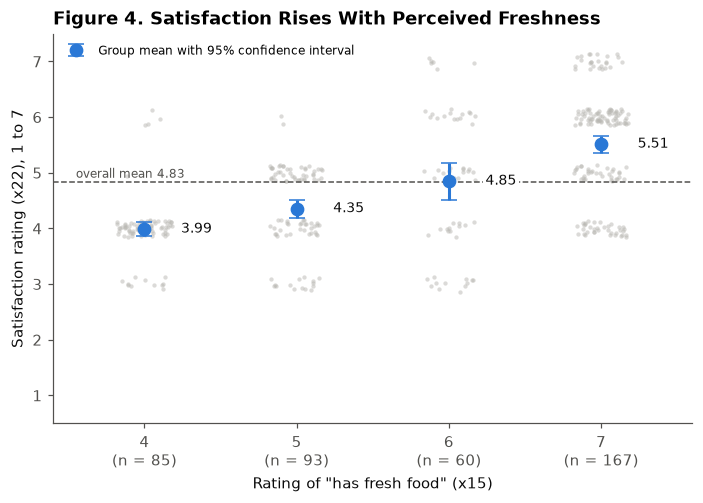

In [21]:
means = group_stats["mean"]
se = group_stats["sd"] / np.sqrt(group_stats["n"])
t_mult = stats.t.ppf(0.975, group_stats["n"] - 1)
ci_half = t_mult * se

rng = np.random.default_rng(7)  # fixed seed so the jitter looks the same every run
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for g, s in zip(GROUP_LEVELS, groups):
    jitter_x = g + rng.uniform(-0.18, 0.18, len(s))
    jitter_y = s + rng.uniform(-0.15, 0.15, len(s))
    ax.scatter(jitter_x, jitter_y, s=8, color="#b8b7b2", alpha=0.5, lw=0)
ax.errorbar(GROUP_LEVELS, means, yerr=ci_half, fmt="o", color=BLUE, ms=8, lw=2, capsize=5,
            label="Group mean with 95% confidence interval")
for g, m in zip(GROUP_LEVELS, means):
    ax.text(g + 0.24, m, f"{m:.2f}", va="center", color=INK, fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
ax.axhline(grand_mean, color=MUTED, ls="--", lw=1)
ax.text(3.55, grand_mean + 0.08, f"overall mean {grand_mean:.2f}", color=MUTED, fontsize=8)
ax.set_xticks(GROUP_LEVELS, [f"{g}\n(n = {len(s)})" for g, s in zip(GROUP_LEVELS, groups)])
ax.set_xlabel("Rating of \"has fresh food\" (x15)")
ax.set_ylabel("Satisfaction rating (x22), 1 to 7")
ax.set_ylim(0.5, 7.5); ax.set_xlim(3.4, 7.6)
ax.legend(frameon=False, loc="upper left", fontsize=8)
ax.set_title("Figure 4. Satisfaction Rises With Perceived Freshness", loc="left")
fig.savefig(os.path.join(FIG_DIR, "Figure 4 - Mean Satisfaction by Freshness.png"))
plt.show()

> **How to Defend This (Figure 4).** Each blue dot is a group's mean satisfaction and the bar around it is
> the 95% confidence interval for that mean. The grey dots are the individual answers, spread slightly so
> they do not sit on top of each other. The means climb from 3.99 to 5.51
> and the intervals do not overlap much, which is the picture behind the significant F. The grey dots also
> show how much individual customers vary inside each group: freshness explains a lot, not everything.

In [22]:
decision = "Reject H0" if p_value < ALPHA else "Fail to reject H0"
print(f"{decision}: F({df_between}, {df_within}) = {F_stat:.2f}, p = {p_value:.2e} (alpha = {ALPHA}).")
print(f"Effect size: eta squared = {eta_sq:.3f}.")
print(f"Mean satisfaction by freshness rating: " +
      ", ".join(f"{g} -> {m:.2f}" for g, m in zip(GROUP_LEVELS, means)))

Reject H0: F(3, 401) = 61.72, p = 7.92e-33 (alpha = 0.05).
Effect size: eta squared = 0.316.
Mean satisfaction by freshness rating: 4 -> 3.99, 5 -> 4.35, 6 -> 4.85, 7 -> 5.51


**Plain-Language Conclusion (alpha = 0.05).** There is a statistically significant difference in
satisfaction across freshness ratings, F(3, 401) = 61.72, p < 0.001, so H0 is
rejected. Customers who rate the food as fresher are more satisfied on average: from
3.99 at a rating of 4 to 5.51 at a rating of 7. Welch's ANOVA and
Kruskal-Wallis agree.

## Task 5. Diagnostic Analytics Report

**What happened.** Among the ten things customers were asked about, food quality is most closely
tied to how satisfied they are and whether they will return or recommend. Fresh food has the strongest
link with satisfaction (r = 0.56), followed by food temperature
(r = 0.50); the interior and atmosphere matter least.

**Why (the diagnostic test).** Mean satisfaction differs across freshness ratings,
F(3, 401) = 61.72, p < 0.001, rising steadily from 3.99 (rating 4)
to 5.51 (rating 7). The result holds under Welch's ANOVA and Kruskal-Wallis, which were
used because the equal-variance and normality assumptions were not met.

**Statistical significance versus practical importance.** With 405 respondents, even small effects are
statistically significant (any |r| above 0.097 would be), so the p-value alone says little about
importance. The practical size is what makes this finding matter:

- Freshness level explains about **32%** of the variation in satisfaction (eta squared =
  0.316, a large effect).
- The gap between customers who gave freshness a 4 and those who gave it a 7 is
  **1.53 points** on a 7-point scale, more than a full step
  (for example from "neutral" to "satisfied").
- By contrast, some Part A correlations such as attractive interior with satisfaction
  (r = 0.20) are significant but weak, so they would be a poor place to invest.

**Cautions.**

1. This is a survey, not an experiment, so the result shows association, not cause. Freshness ratings may
   rise and fall with other things that also drive satisfaction.
2. Freshness and taste are very strongly correlated (r = 0.79), so part of the
   "freshness effect" may really be a taste effect; this analysis cannot separate the two.
3. Nobody rated freshness below 4, so we know nothing about customers who find the food stale.
4. The 1 to 7 scores were treated as numbers; the rank-based Kruskal-Wallis result guards against that.

**Recommended next step.** Separate freshness from taste. For example, compare satisfaction across
freshness ratings **within** customers who gave the same taste rating, or include both in a regression.
If freshness still matters on its own, test it for real: change one freshness practice (such as daily
produce delivery) for a set period and compare satisfaction before and after.

**Oral Explanation (about 60 seconds).** "We asked whether customers who rate the food as fresher are
more satisfied. Freshness was the strongest correlate of satisfaction, so we compared mean satisfaction
across the four freshness ratings with a one-way ANOVA. The difference is significant, F(3,
401) = 61.72, p below 0.001, and it is large: freshness explains about 32% of the
variation in satisfaction, and customers who rate freshness 7 are 1.53
points more satisfied than those who rate it 4. Two assumptions, normality and equal variances, were not
met, so we confirmed the result with Welch's ANOVA and Kruskal-Wallis, which agree. This is survey
data, so it shows association, not cause, and freshness overlaps heavily with taste. Our next step
would be to separate the two."

## Question and Answer

**1. Why does rejecting the null hypothesis not automatically prove that one variable causes another?**

Rejecting H0 only shows that the pattern in the data (here, different mean satisfaction across freshness
ratings) would be very unlikely if there were truly no relationship. It says nothing about direction or
mechanism. The data come from a survey, not an experiment, so freshness was not controlled or assigned.
A third factor, such as overall food quality or taste (which correlates 0.79 with
freshness), could drive both ratings, and a satisfied customer may also simply rate everything higher.
Only a controlled experiment, or a design that rules out these alternatives, can support a causal claim.

**2. How should a researcher respond when the assumptions of the selected test are not satisfied?**

First, check and report the violation openly instead of ignoring it, with the evidence (here, Shapiro-Wilk
and Levene tests and the histograms). Then judge how serious it is: ANOVA tolerates non-normality well
with large groups, but unequal variances with unequal group sizes can distort the F-test. Next, use a
remedy that does not need the failed assumption, such as Welch's ANOVA for unequal variances or the
Kruskal-Wallis test for non-normal data, or transform the data where that makes sense. Finally, compare
the results: if they agree, as they did here, the conclusion is robust; if they disagree, report the more
cautious result and state the limitation.

**3. Why should statistical significance be discussed together with practical significance?**

Statistical significance only says an effect is unlikely to be zero; it does not say the effect is big
enough to matter. The p-value depends heavily on sample size: with 405 respondents, a correlation as
small as 0.10 is "significant" even though it is practically meaningless. Practical significance
uses effect sizes (eta squared = 0.32, a mean gap of 1.53
points) to show whether the difference is large enough to justify a decision, such as spending money on
fresher ingredients. Reporting both prevents over-selling trivial effects and under-selling important ones.

## Appendix: AI Tools and Prompts

The course allows AI for data cleaning, scripts, EDA and charts, and hypothesis testing, provided that the
prompts, outputs, verification steps and corrections are documented. This appendix does that.

**Tool used.** Claude Code (Anthropic), model Claude Opus 5.5, running on my own computer. It wrote the
Python code and the Excel formulas, ran them, and drafted the explanations. The analysis uses pandas,
NumPy, SciPy and matplotlib; the workbook uses Microsoft Excel formulas.

**Prompts I gave.**

1. "Build the M2-Technical in two versions: a full version with the code actually executed so every number
   comes from real output, with a short plain-language 'how to defend this' note beside each metric,
   p-value and chart, plus an appendix naming the AI tools and prompts; and a practice version with the code
   removed, where each step keeps its instructions, a hint and a check cell. Also a one-page instruction
   sheet." (paraphrased from my original request)
2. Answers to the tool's follow-up questions: the dataset is `Customer_Satisfaction.xlsx`, I am doing the whole
   analysis, and the output should be a Jupyter notebook and an Excel workbook.

**What the AI produced.** The cleaning checks, the correlation analysis (Part A), the choice of one-way ANOVA
on freshness and satisfaction, the assumption checks and remedies, the post-hoc test, the four figures, and
first drafts of the report and the Q&A answers.

**How the outputs were verified.**

1. Every number in the text is filled in from the executed code, not typed by hand.
2. The ANOVA was computed by hand (sums of squares) and matched SciPy's `f_oneway` exactly; SSB + SSW = SST.
3. Welch's F from SciPy matched a hand-coded Welch formula.
4. The same analysis was rebuilt independently with Excel formulas in the companion workbook; the Python and
   Excel values match (differences only in far decimal places, noted in the workbook).
5. Pearson results were cross-checked against Spearman (largest difference 0.068).
6. I re-ran the whole notebook from top to bottom myself and worked through the practice version, so I can
   explain each step without AI.

**Corrections made.**

1. SciPy's Levene test defaults to median-centering (the Brown-Forsythe version, F = 19.14). It was
   switched to the classic mean-centered Levene (F = 38.60) so Python and Excel compute the same
   statistic; both show unequal variances, so the conclusion did not change.
2. The raw sheet contains the instructor's task note in extra columns; these were excluded from the data.
3. The AI's first plan used only the standard ANOVA; after the assumption checks failed, Welch's ANOVA and
   Kruskal-Wallis were added and the conclusion was based on all three agreeing.